# Electricity Peak Demand Prediction System – Model Analysis

This notebook demonstrates the machine learning process used to predict
high electricity demand days using historical load and weather data.

Steps covered:
1. Data loading
2. Data visualization
3. Feature selection
4. Model training
5. Model evaluation
6. Model comparison

## Dataset Description

The dataset contains daily electricity demand information derived from
hourly load data. It also includes weather features such as temperature
and humidity.

Target variable:
Peak_Day → 1 if the day experienced unusually high electricity demand,
otherwise 0.

In [18]:
import pandas as pd

data = pd.read_csv("data/processed/daily_data.csv")
data.head()

,Date,Daily_Max_Load,Max_Temperature,Avg_Humidity,Month,Year,IsWeekend,YearMonth,Peak_Day
0,2012-10-01,15094.0,288.961048,56.416667,10,2012,0,2012-10,0
1,2012-10-02,15921.0,294.850000,50.500000,10,2012,0,2012-10,0
2,2012-10-03,15553.0,292.880000,68.541667,10,2012,0,2012-10,0
3,2012-10-04,15569.0,295.270000,95.000000,10,2012,0,2012-10,0
4,2012-10-05,15189.0,296.270000,93.041667,10,2012,0,2012-10,0


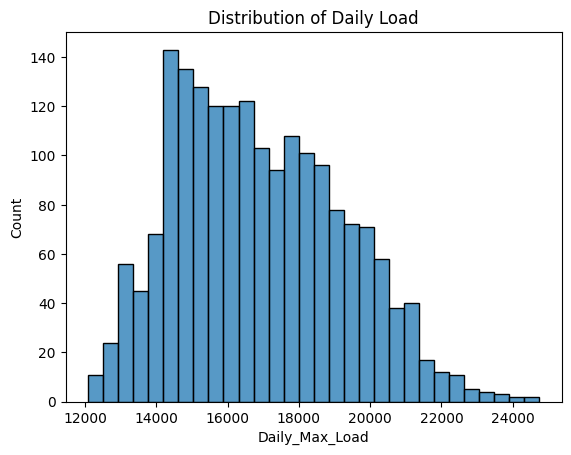

In [19]:
sns.histplot(data["Daily_Max_Load"], bins=30)
plt.title("Distribution of Daily Load")
plt.show()

## Peak Day Distribution

This graph shows how many days were classified as peak demand days.
Peak days are rare events, which creates a class imbalance problem
in the dataset.

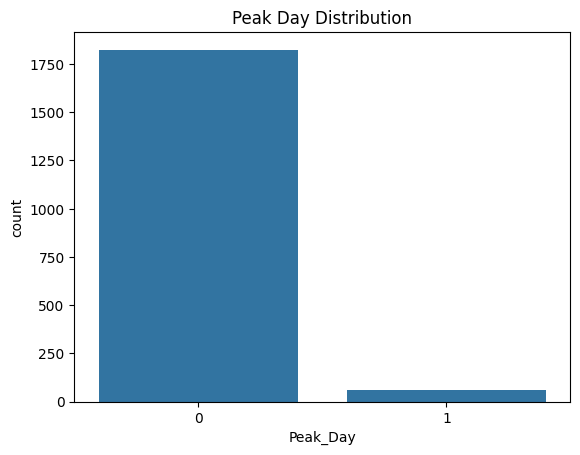

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=data["Peak_Day"])
plt.title("Peak Day Distribution")
plt.show()

## Temperature vs Load

Electricity demand often increases with temperature due to
cooling requirements such as air conditioning.
This plot shows the relationship between temperature and load.

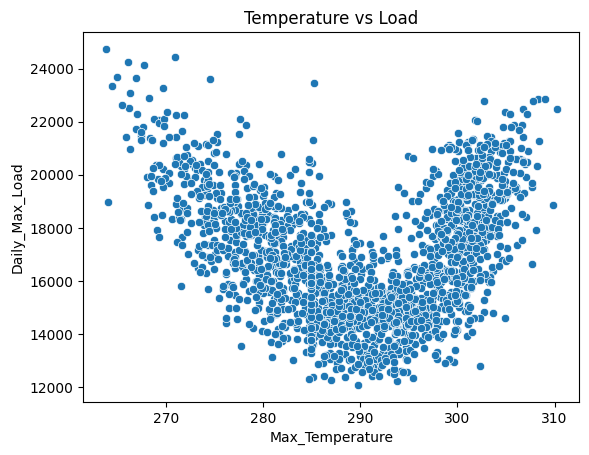

In [21]:
sns.scatterplot(x=data["Max_Temperature"], y=data["Daily_Max_Load"])
plt.title("Temperature vs Load")
plt.show()

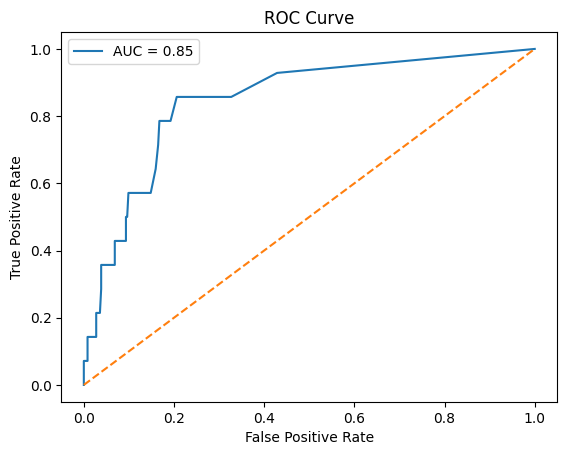

In [22]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

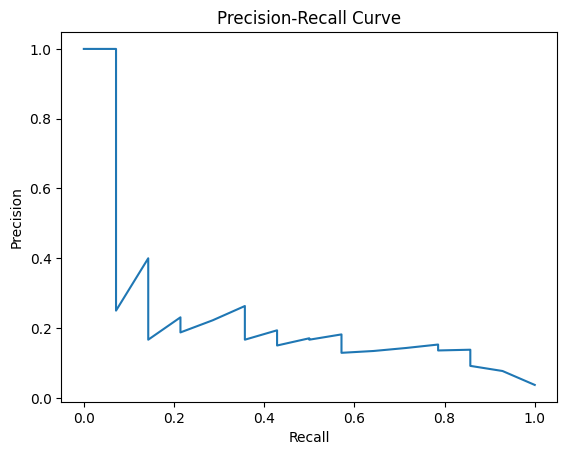

In [29]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Feature Selection

The following features are used to train the peak day prediction model:

- Daily_Max_Load
- Max_Temperature
- Avg_Humidity
- Month
- IsWeekend

These variables capture seasonal, weather, and behavioral patterns
that influence electricity demand.

In [23]:
from sklearn.model_selection import train_test_split

features = [
    "Daily_Max_Load",
    "Max_Temperature",
    "Avg_Humidity",
    "Month",
    "IsWeekend"
]

X = data[features]
y = data["Peak_Day"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

A Random Forest classifier is used to predict peak demand days.
Random Forest was chosen because it handles non-linear relationships
well and provides feature importance for interpretation.

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Confusion Matrix

The confusion matrix evaluates the model’s performance by showing:

- True Positives
- True Negatives
- False Positives
- False Negatives

This helps understand how well the model detects peak days.

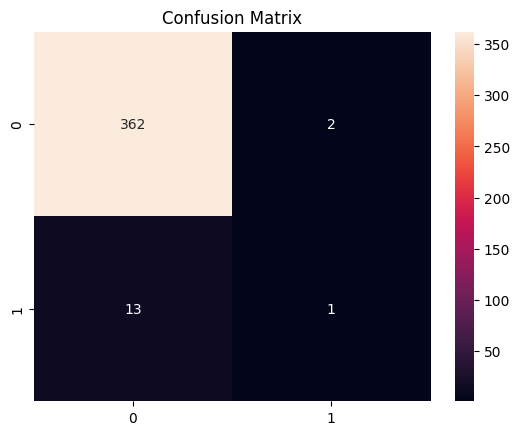

In [25]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

Random Forest provides a measure of feature importance.
This graph shows which variables contribute most to predicting
peak demand.

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       364
           1       0.33      0.07      0.12        14

    accuracy                           0.96       378
   macro avg       0.65      0.53      0.55       378
weighted avg       0.94      0.96      0.95       378



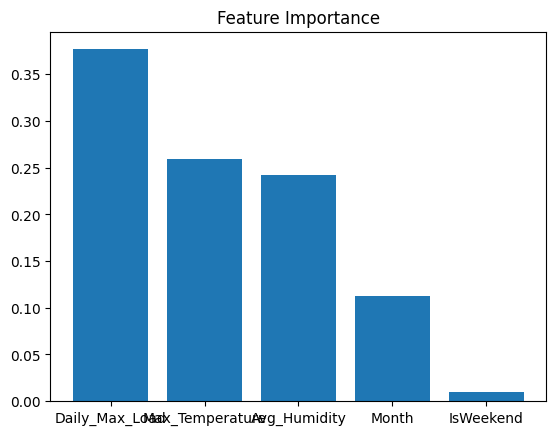

In [27]:
importance = model.feature_importances_

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

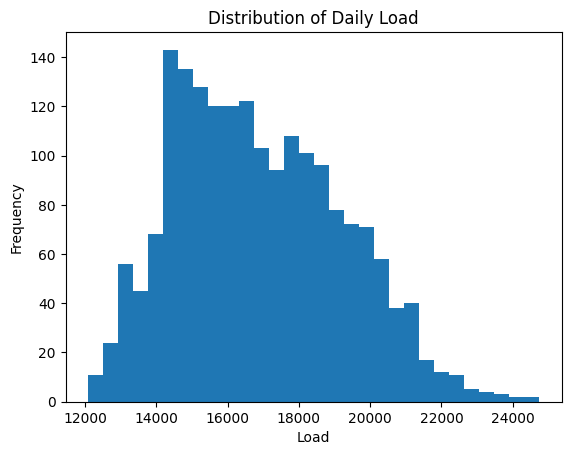

In [30]:
plt.hist(data["Daily_Max_Load"], bins=30)

plt.title("Distribution of Daily Load")
plt.xlabel("Load")
plt.ylabel("Frequency")

plt.show()

## Model Comparison

Two models were compared:

• Logistic Regression  
• Random Forest

Random Forest performs better because it captures
non-linear relationships between weather and demand.

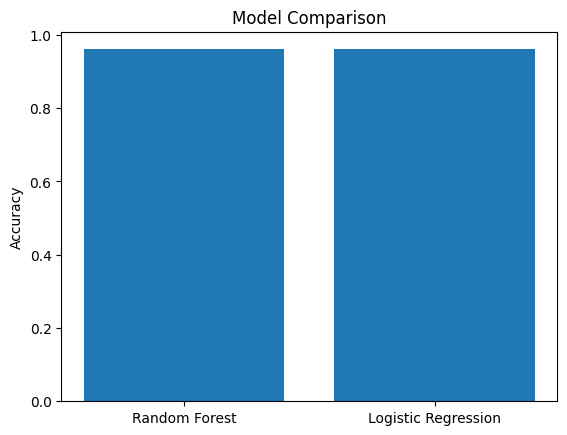

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred)
lr_acc = accuracy_score(y_test, lr_pred)

models = ["Random Forest", "Logistic Regression"]
scores = [rf_acc, lr_acc]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

## Conclusion

The Random Forest model successfully identifies high-demand days
using load and weather features.

Key findings:
- Temperature and load strongly influence electricity demand.
- Peak days are rare but predictable.
- Random Forest performs better than Logistic Regression for this task.

The trained model is later integrated into a Streamlit dashboard
for visualization and analysis.